---

# Wine Quality Classification with Decision Trees

A decision tree is a supervised learning algorithm that makes predictions by learning a hierarchy of if-else rules from the training data. Each internal node represents a decision based on a feature value, each branch represents an outcome of that decision, and each leaf node represents a predicted class.

In this notebook, we apply a decision tree classifier to the Wine Quality dataset to predict whether a red wine is of high or low quality based on its chemical properties.

---

In [19]:
# Standard data manipulation and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Our own DecisionTree implementation from ml_pack
from ml_pack import DecisionTree

# Sklearn tools for preprocessing and evaluation only
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

---

## Loading and Exploring the Data

---

In [20]:
# Load the Wine Quality dataset
df = pd.read_csv("wine_quality.csv")

# Check dimensions and preview
print(df.shape)
df.head()

(1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [21]:
df.info()
print()
print("Quality distribution:")
print(df['quality'].value_counts().sort_index())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB

Quality distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


---

## Defining Features and Target

Since most wines are rated 5 or 6, we convert quality into a binary target — wines rated 7 or above are considered high quality (1) and wines rated below 7 are considered low quality (0).

---

In [22]:
# Convert quality to binary target
df['high_quality'] = (df['quality'] >= 7).astype(int)

# Separate features and target
X = df.drop(columns=['quality', 'high_quality']).values
y = df['high_quality'].values

print("Feature matrix shape:", X.shape)
print("Class distribution:", dict(zip(*np.unique(y, return_counts=True))))

Feature matrix shape: (1599, 11)
Class distribution: {np.int64(0): np.int64(1382), np.int64(1): np.int64(217)}


---

## Splitting and Scaling the Data

---

In [23]:
# Split into 80% training and 20% test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train_scaled.shape)
print("Test set size:", X_test_scaled.shape)

Training set size: (1279, 11)
Test set size: (320, 11)


---

## Training the Decision Tree

We train a decision tree classifier and limit the depth to avoid overfitting.

---

In [24]:
# Train our custom decision tree with max depth of 5
tree = DecisionTree(max_depth=5, random_state=42)
tree.fit(X_train_scaled, y_train)

# Evaluate on test set
y_pred = tree.predict(X_test_scaled)

print(classification_report(y_test, y_pred, target_names=['Low Quality', 'High Quality']))

              precision    recall  f1-score   support

 Low Quality       0.90      0.96      0.93       273
High Quality       0.59      0.36      0.45        47

    accuracy                           0.87       320
   macro avg       0.74      0.66      0.69       320
weighted avg       0.85      0.87      0.86       320



---

## Visualizing the Confusion Matrix

---

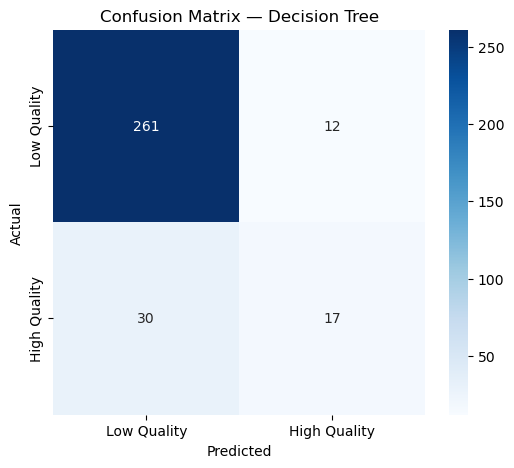

In [25]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Quality', 'High Quality'],
            yticklabels=['Low Quality', 'High Quality'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Decision Tree")
plt.show()

---

## Feature Importance

Decision trees provide a built-in measure of feature importance based on how much each feature reduces impurity across all splits.

---

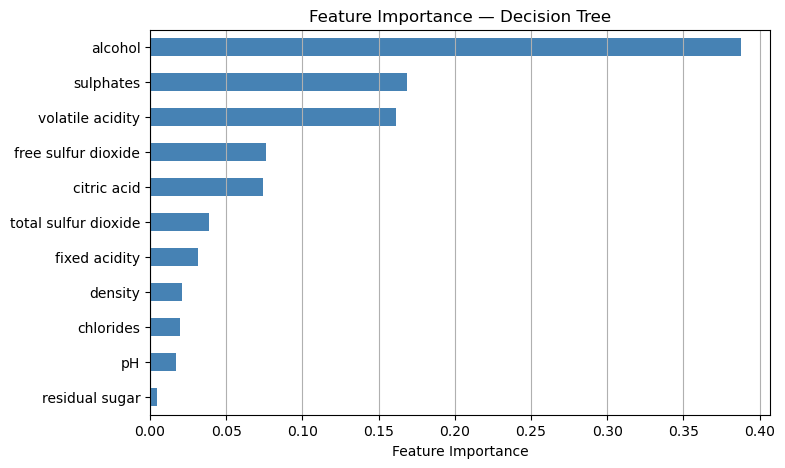

In [26]:
# Plot feature importances from our ml_pack DecisionTree
feature_names = df.drop(columns=['quality', 'high_quality']).columns.tolist()
feature_importances = pd.Series(tree.feature_importances_, index=feature_names)
feature_importances_sorted = feature_importances.sort_values()

plt.figure(figsize=(8, 5))
feature_importances_sorted.plot(kind='barh', color='steelblue')
plt.xlabel("Feature Importance")
plt.title("Feature Importance — Decision Tree")
plt.grid(True, axis='x')
plt.show()

---

## Summary

In this notebook we applied a decision tree classifier to predict wine quality using chemical properties. The model achieved 87% accuracy on the test set with a max depth of 5.

Key takeaways:
- Decision trees are highly interpretable — the learned rules can be visualized directly
- Limiting tree depth prevents overfitting at the cost of some accuracy
- Alcohol content and sulphates were the most important features for predicting wine quality
- The class imbalance between high and low quality wines made it harder to correctly classify high quality wines
- Ensemble methods like Random Forests build on decision trees to improve performance

---